In [16]:
import pandas as pd
import plotnine as p9
import numpy as np
import os

In [17]:
PLOT_DIR = 'data/general_plots'
os.makedirs(PLOT_DIR, exist_ok=True)

In [18]:
pdmorl_file = 'data/pdmorl_stats.csv'
pcpl_file = 'data/pcpl_stats.csv'
envelope_file = 'data/envelope_stats.csv'
psl_file = 'data/psl_stats.csv'

In [19]:
pdmorl = pd.read_csv(pdmorl_file)
pdmorl

,problem,config,checkpoint,hypervolume,normalized_hv,percent_non_dominated,ordering_score,pref_grid_step,tau,learning_rate,gamma,batch_size,seed,timestamp
0,problem_0,problem_0.yml,NaN,429.418930,0.958043,0.769231,0.996933,0.05,0.001,0.0003,0.95,128,0,2026-05-28T01:38:57
1,problem_0,problem_0.yml,NaN,433.618266,0.967412,0.923077,0.996951,0.05,0.001,0.0003,0.95,128,2,2026-05-28T01:39:10
2,problem_0,problem_0.yml,NaN,444.383744,0.991430,1.000000,1.000000,0.05,0.001,0.0003,0.95,128,1,2026-05-28T01:39:19
3,problem_0,problem_0.yml,NaN,435.234523,0.971018,1.000000,1.000000,0.05,0.001,0.0003,0.95,128,3,2026-05-28T01:39:26
4,problem_1a,problem_1a.yml,NaN,151.549396,0.714348,0.769231,0.971211,0.05,0.005,0.0003,0.99,256,0,2026-05-28T02:31:23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,problem_5e,problem_5e.yml,NaN,279902.231572,0.616421,0.673626,0.732625,0.05,0.005,0.0010,0.99,128,0,2026-05-28T19:19:35
76,problem_5e,problem_5e.yml,NaN,189208.591560,0.416689,0.618132,0.514076,0.05,0.005,0.0010,0.99,128,1,2026-05-28T19:45:22
77,problem_5e,problem_5e.yml,NaN,132267.236668,0.291289,0.761538,0.546923,0.05,0.005,0.0010,0.99,128,2,2026-05-28T19:47:16
78,problem_5e,problem_5e.yml,NaN,298545.475350,0.657479,0.508242,0.473819,0.05,0.005,0.0010,0.99,128,3,2026-05-28T19:53:38


In [20]:
pcpl = pd.read_csv(pcpl_file)
pcpl

,env_name,hypervolume,normalized_hv,non_dominated,ordering,architecture_idx,clip_range,entropy,lr,n_epochs,n_steps,scalarization_method,seed,smoothness,target_kl,sweep_timesteps,wandb_run_name
0,problem_0,448.225042,1.000000,1.000000,1.000000,0,0.226605,0.005462,0.000053,20,2048,smooth_tchebycheff,0,0.019041,0.013451,200000,morning-sweep-28
1,problem_0,448.225042,1.000000,1.000000,1.000000,0,0.226605,0.005462,0.000053,20,2048,smooth_tchebycheff,1,0.019041,0.013451,200000,morning-sweep-28
2,problem_0,448.225042,1.000000,1.000000,1.000000,0,0.226605,0.005462,0.000053,20,2048,smooth_tchebycheff,2,0.019041,0.013451,200000,morning-sweep-28
3,problem_0,448.225042,1.000000,1.000000,1.000000,0,0.226605,0.005462,0.000053,20,2048,smooth_tchebycheff,3,0.019041,0.013451,200000,morning-sweep-28
4,problem_0,448.225042,1.000000,1.000000,1.000000,0,0.226605,0.005462,0.000053,20,2048,smooth_tchebycheff,4,0.019041,0.013451,200000,morning-sweep-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,problem_5e,303117.234128,0.667547,0.513187,0.799340,0,0.192599,0.062361,0.000099,20,2048,smooth_tchebycheff,0,0.064093,0.016039,200000,dazzling-sweep-24
76,problem_5e,353156.928304,0.777748,0.740110,0.776913,0,0.192599,0.062361,0.000099,20,2048,smooth_tchebycheff,1,0.064093,0.016039,200000,dazzling-sweep-24
77,problem_5e,350523.593290,0.771949,0.450000,0.755175,0,0.192599,0.062361,0.000099,20,2048,smooth_tchebycheff,2,0.064093,0.016039,200000,dazzling-sweep-24
78,problem_5e,391590.687354,0.862390,0.447802,0.717022,0,0.192599,0.062361,0.000099,20,2048,smooth_tchebycheff,3,0.064093,0.016039,200000,dazzling-sweep-24


In [21]:
envelope = pd.read_csv(envelope_file)
envelope

,problem,config,checkpoint,hypervolume,normalized_hv,percent_non_dominated,ordering_score,pref_grid_step,lr,gamma,batch_size,seed,timestamp
0,problem_1a,problem_1a.yml,NaN,131.290527,0.618855,0.230769,0.955396,0.05,0.0010,0.99,32,0,2026-06-03T15:47:59
1,problem_1a,problem_1a.yml,NaN,71.576260,0.337384,0.461538,0.986984,0.05,0.0010,0.99,32,1,2026-06-03T17:00:56
2,problem_1a,problem_1a.yml,NaN,38.861872,0.183181,1.000000,0.991225,0.05,0.0010,0.99,32,2,2026-06-03T18:01:04
3,problem_1a,problem_1a.yml,NaN,74.484198,0.351091,0.153846,0.979472,0.05,0.0010,0.99,32,3,2026-06-03T19:14:25
4,problem_0,problem_0.yml,NaN,398.320845,0.888663,0.846154,0.901185,0.05,0.0003,0.95,128,2,2026-06-03T19:16:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,problem_5e,problem_5e.yml,NaN,280026.075319,0.616694,0.707692,0.819909,0.05,0.0003,0.95,128,0,2026-06-06T10:55:59
76,problem_5e,problem_5e.yml,NaN,198228.523528,0.436553,0.825275,0.711995,0.05,0.0003,0.95,128,1,2026-06-06T11:33:32
77,problem_5e,problem_5e.yml,NaN,214659.123723,0.472738,0.750000,0.722636,0.05,0.0003,0.95,128,3,2026-06-06T17:41:23
78,problem_5e,problem_5e.yml,NaN,193234.147709,0.425554,0.737912,0.762691,0.05,0.0003,0.95,128,2,2026-06-06T18:26:10


In [22]:
def to_plot_df(
        df, 
        problem_col = 'problem', 
        metric_map = {
            'normalized_hv': 'HV Ratio',
            'percent_non_dominated': '% Non-Dominated',
            'ordering_score': 'Ordering Score',
        },
        run_idx = 'seed',
):
    """Extract, tidy, and pretify names."""
    plot_df = ( 
        df[[problem_col] + [k for k in metric_map.keys()] + [run_idx]]
        .set_index([problem_col, run_idx])
        .rename_axis('metric',axis=1)
        .stack()
    ).rename('score').reset_index()
    plot_df['metric'] = pd.Categorical(
        values=plot_df['metric'].map(metric_map),
        categories=[v for _,v in metric_map.items()],
        ordered=True
    )
    plot_df.rename(columns={problem_col:'Problem'}, inplace=True)
    plot_df['Problem'] = plot_df['Problem'].map({n:n.split('_')[1] for n in plot_df['Problem'].unique()})
    return plot_df

In [23]:
pdmorl_plot = to_plot_df(pdmorl)
display(pdmorl_plot.head(3))
pdmorl_plot.groupby(by='metric', observed=True)['score'].describe()

,Problem,seed,metric,score
0,0,0,HV Ratio,0.958043
1,0,0,% Non-Dominated,0.769231
2,0,0,Ordering Score,0.996933


,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
HV Ratio,80.0,0.486862,0.304548,0.000477,0.244899,0.528948,0.658928,0.99143
% Non-Dominated,80.0,0.614863,0.267921,0.004396,0.472527,0.615385,0.788462,1.00000
Ordering Score,80.0,0.821784,0.162088,0.394898,0.687536,0.864878,0.970452,1.00000


In [24]:
pcpl_plot = to_plot_df(
    pcpl,
    problem_col='env_name',
    metric_map = {
        'normalized_hv': 'HV Ratio',
        'non_dominated': '% Non-Dominated',
        'ordering': 'Ordering Score',
    },    
    run_idx = 'seed',
)

In [25]:
envelope_plot = to_plot_df(envelope)
display(envelope_plot.head(3))
envelope_plot.groupby(by='metric', observed=True)['score'].describe()

,Problem,seed,metric,score
0,1a,0,HV Ratio,0.618855
1,1a,0,% Non-Dominated,0.230769
2,1a,0,Ordering Score,0.955396


,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
HV Ratio,80.0,0.375508,0.260273,0.011002,0.121602,0.415358,0.559945,0.913072
% Non-Dominated,80.0,0.410398,0.284228,0.013736,0.153846,0.379121,0.671703,1.000000
Ordering Score,80.0,0.763648,0.146463,0.351081,0.674874,0.763470,0.877991,0.996250


In [26]:
psl = pd.read_csv(psl_file)
psl_plot = to_plot_df(psl)
display(psl_plot.head(3))
psl_plot.groupby(by='metric', observed=True)['score'].describe()

,Problem,seed,metric,score
0,0,0,HV Ratio,1.0
1,0,0,% Non-Dominated,1.0
2,0,0,Ordering Score,1.0


,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
HV Ratio,80.0,0.780575,0.259671,0.004398,0.734946,0.881720,0.963571,1.0
% Non-Dominated,80.0,0.543297,0.294427,0.048901,0.266758,0.601923,0.769231,1.0
Ordering Score,80.0,0.881920,0.128327,0.506968,0.816740,0.929705,0.995246,1.0


In [27]:
display(pcpl_plot.head(3))
pcpl_plot.groupby(by=['metric'], observed=True)['score'].describe()

,Problem,seed,metric,score
0,0,0,HV Ratio,1.0
1,0,0,% Non-Dominated,1.0
2,0,0,Ordering Score,1.0


,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
HV Ratio,80.0,0.704710,0.234284,0.143459,0.554899,0.736073,0.891389,1.0
% Non-Dominated,80.0,0.613585,0.308628,0.047802,0.353159,0.615385,0.923489,1.0
Ordering Score,80.0,0.911791,0.096253,0.601228,0.874690,0.943194,0.993002,1.0


In [28]:
plot_df = pd.concat([
    pdmorl_plot.assign(Architecture='PD-MORL'),
    pcpl_plot.assign(Architecture='PCPL-PPO'),
    envelope_plot.assign(Architecture='Envelope'),
    psl_plot.assign(Architecture='PSL'),
], ignore_index=True)
plot_df['Architecture'] = pd.Categorical(
    plot_df['Architecture'],
    categories=['PCPL-PPO', 'PD-MORL', 'Envelope', 'PSL'],
    ordered=True,
)
plot_df['Subproblem'] = plot_df['Problem'].apply(lambda s: s[1:])
plot_df['Problem Set'] = plot_df['Problem'].apply(lambda s: s[0])

_problem_order = sorted(plot_df['Problem'].unique())
plot_df['x_pos'] = plot_df['Problem'].map({p: i+1 for i, p in enumerate(_problem_order)})
_sep_xintercepts = [1.5, 4.5, 7.5, 9.5, 11.5]
_x_breaks = list(range(1, len(_problem_order) + 1))
plot_df

,Problem,seed,metric,score,Architecture,Subproblem,Problem Set,x_pos
0,0,0,HV Ratio,0.958043,PD-MORL,,0,1
1,0,0,% Non-Dominated,0.769231,PD-MORL,,0,1
2,0,0,Ordering Score,0.996933,PD-MORL,,0,1
3,0,2,HV Ratio,0.967412,PD-MORL,,0,1
4,0,2,% Non-Dominated,0.923077,PD-MORL,,0,1
...,...,...,...,...,...,...,...,...
955,5e,3,% Non-Dominated,0.730220,PSL,e,5,16
956,5e,3,Ordering Score,0.857509,PSL,e,5,16
957,5e,4,HV Ratio,0.879846,PSL,e,5,16
958,5e,4,% Non-Dominated,0.771978,PSL,e,5,16


/Users/zhiheng/Desktop/USC ICT/GraphAllocBench/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.5 x 4.5 in image.
/Users/zhiheng/Desktop/USC ICT/GraphAllocBench/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: data/general_plots/problems1-5_v3.pdf
/Users/zhiheng/Desktop/USC ICT/GraphAllocBench/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.5 x 4.5 in image.
/Users/zhiheng/Desktop/USC ICT/GraphAllocBench/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: data/general_plots/problems1-5_v3.png


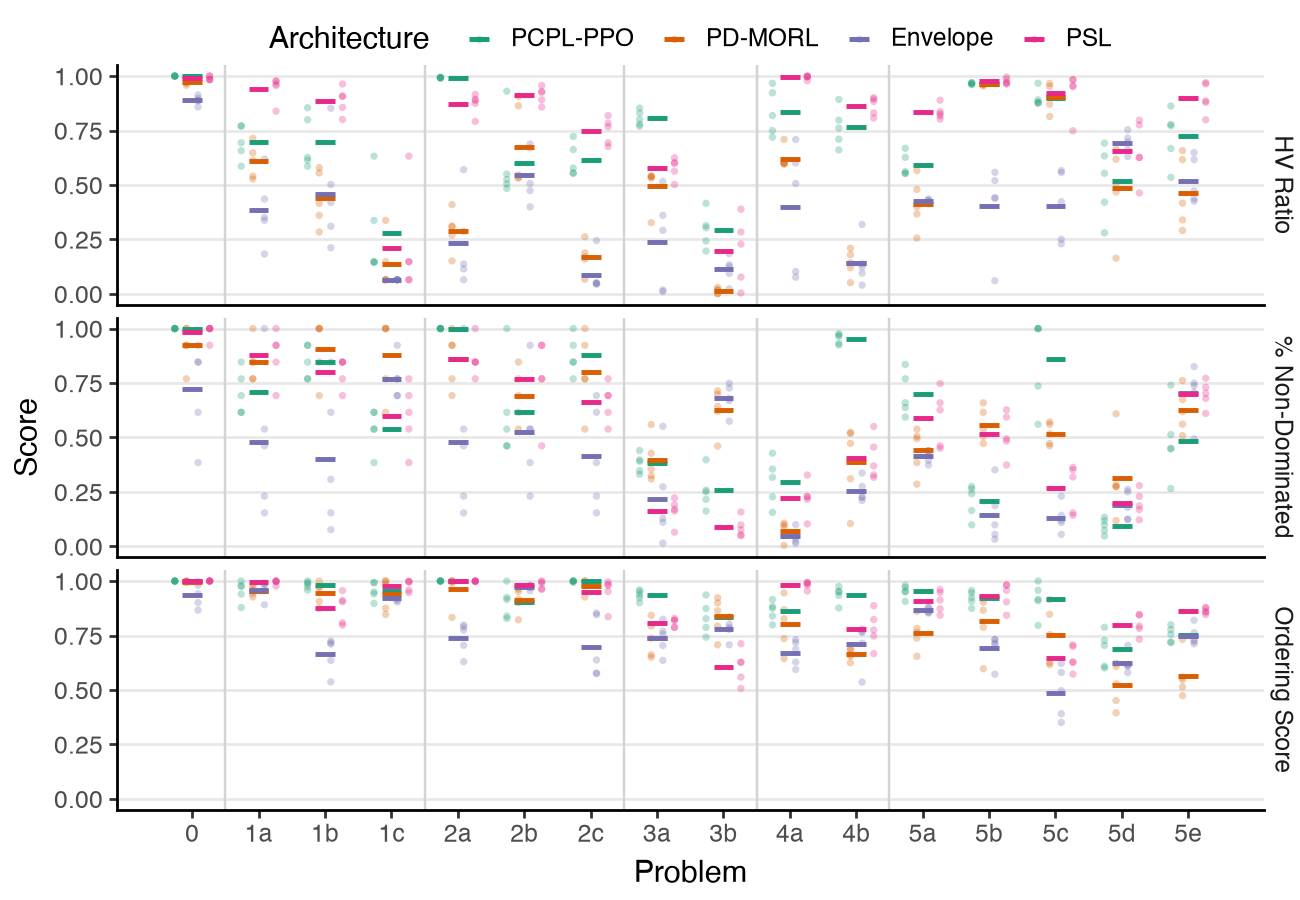

In [29]:
p = (
    p9.ggplot(data=plot_df, mapping=p9.aes(x='x_pos', y='score', fill='Architecture', color='Architecture'))
    + p9.facet_grid('metric~.')
    + p9.geom_vline(xintercept=_sep_xintercepts, color='lightgray', size=0.5)
    + p9.geom_point(
        position=p9.position_dodge(width=0.7),
        color='none',
        alpha=0.3,
        size=1.0,
    )
    + p9.stat_summary(
        geom='point',
        fun_y=np.mean,
        size=3,
        shape='_',
        stroke=1,
    )
    + p9.scale_x_continuous(breaks=_x_breaks, labels=_problem_order)
    + p9.theme_classic()
    + p9.theme(
        figure_size=(6.5,4.5),
        panel_grid_major_y=p9.element_line(color='lightgray', alpha=0.5),
        legend_direction='horizontal',
        legend_position='top',
        legend_box_margin=0,
        legend_box_spacing=0,
        strip_background=p9.element_blank(),
    )
    + p9.scale_color_brewer(type='qual', palette=2)
    + p9.scale_fill_brewer(type='qual', palette=2)
    + p9.xlab('Problem')
    + p9.ylab('Score')
)

p.save(f'{PLOT_DIR}/problems1-5_v3.pdf')
p.save(f'{PLOT_DIR}/problems1-5_v3.png', dpi=600)
display(p)

/Users/zhiheng/Desktop/USC ICT/GraphAllocBench/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.5 x 4.5 in image.
/Users/zhiheng/Desktop/USC ICT/GraphAllocBench/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: data/general_plots/problems1-5_v4.pdf
/Users/zhiheng/Desktop/USC ICT/GraphAllocBench/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.5 x 4.5 in image.
/Users/zhiheng/Desktop/USC ICT/GraphAllocBench/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: data/general_plots/problems1-5_v4.png


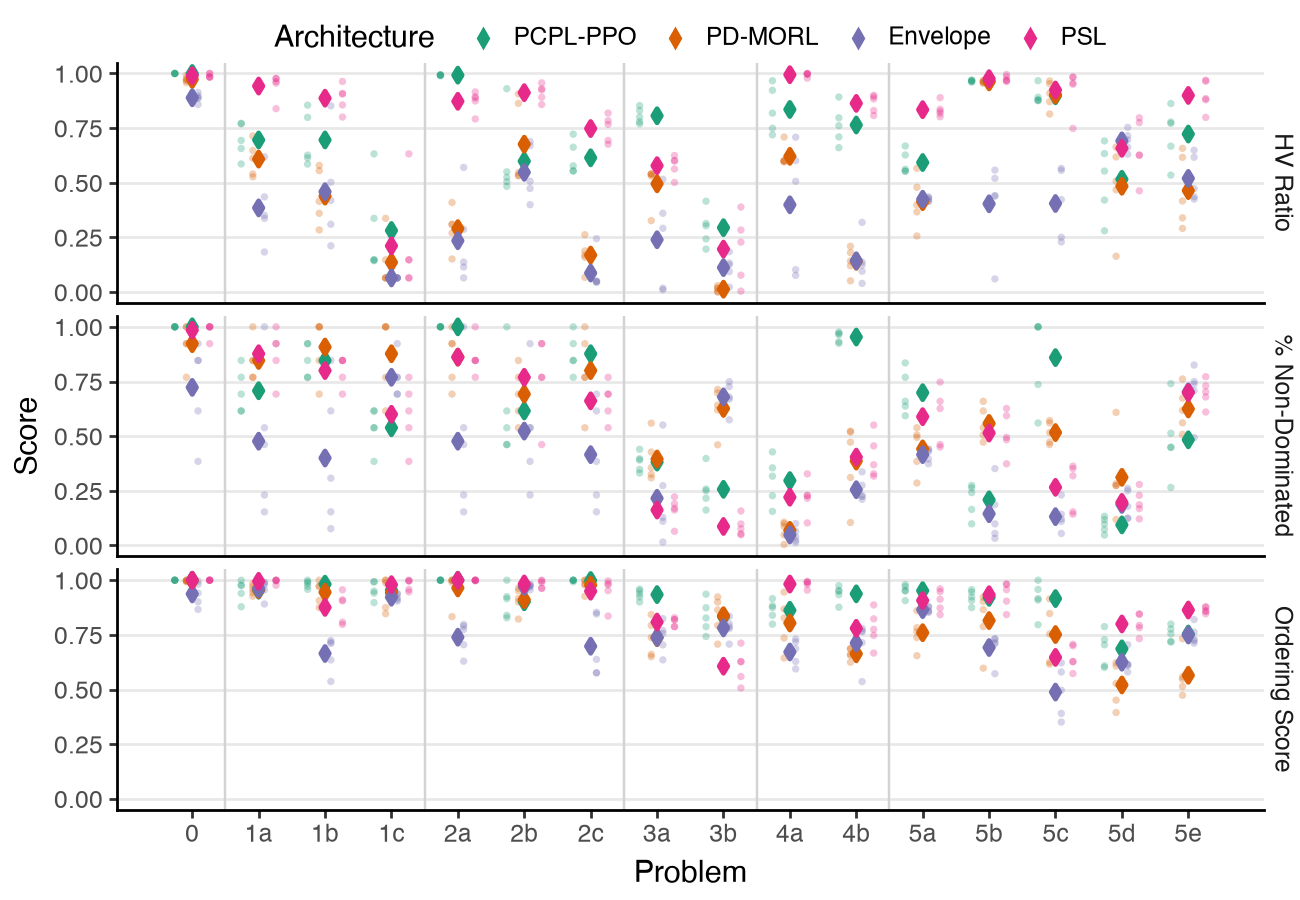

In [30]:
p = (
    p9.ggplot(data=plot_df, mapping=p9.aes(x='x_pos', y='score', fill='Architecture', color='Architecture'))
    + p9.facet_grid('metric~.')
    + p9.geom_vline(xintercept=_sep_xintercepts, color='lightgray', size=0.5)
    + p9.geom_point(
        position=p9.position_dodge(width=0.7),
        color='none',
        alpha=0.3,
        size=1.0,
    )
    + p9.stat_summary(
        geom='point',
        fun_y=np.mean,
        size=1.0,
        shape='d',
        stroke=1,
    )
    + p9.scale_x_continuous(breaks=_x_breaks, labels=_problem_order)
    + p9.theme_classic()
    + p9.theme(
        figure_size=(6.5,4.5),
        panel_grid_major_y=p9.element_line(color='lightgray', alpha=0.5),
        legend_direction='horizontal',
        legend_position='top',
        legend_box_margin=0,
        legend_box_spacing=0,
        strip_background=p9.element_blank(),
    )
    + p9.scale_color_brewer(type='qual', palette=2)
    + p9.scale_fill_brewer(type='qual', palette=2)
    + p9.xlab('Problem')
    + p9.ylab('Score')
)
p.save(f'{PLOT_DIR}/problems1-5_v4.pdf')
p.save(f'{PLOT_DIR}/problems1-5_v4.png', dpi=600)
display(p)